# Cairn: Teaching a Small Model to Triage Like a Large One

**Author:** Rahul Kumar | **Hardware:** 1x A100 40GB SXM4 (Lambda) | **Framework:** [Unsloth](https://github.com/unslothai/unsloth) | **Competition:** [Gemma 4 Good Hackathon](https://kaggle.com/competitions/gemma-4-good-hackathon)

---

## The Problem

In disaster zones and rural clinics, there is no internet — meaning zero access to cloud AI. Community health workers (CHWs) face life-or-death triage decisions with no support. Published research shows LLMs detect critical patients at **87.8% accuracy** vs experienced triage nurses at **32.7%** ([Arslan et al., AJEM 2025](https://doi.org/10.1016/j.ajem.2024.12.001)). The capability exists — the deployment gap is the problem.

But there's a catch: **base models over-triage everything as RED.** Paper cuts become emergencies. If everything is RED, nothing is prioritized — triage becomes useless.

## Our Fix: Teacher-Student Distillation

We use Gemma 4 **26B-A4B** (LMArena #44, 88.3% AIME 2026) as a **teacher** to generate gold-standard triage responses for clinical scenarios grounded in **WHO ETAT** and **ESI** triage frameworks. Then we fine-tune the smaller **E4B** (student) to reproduce that calibration. We're not teaching medicine — E4B already knows that from pre-training. We're teaching **when to say GREEN vs YELLOW vs RED.**

This mirrors real medical education: attending physicians (26B) train residents (E4B) through supervised cases.

## This Notebook

| Step | What | Why |
|------|------|-----|
| 1-2 | Install + Load E4B via `FastVisionModel` (16-bit) | Official Unsloth Gemma 4 pattern — required for GGUF export |
| 3 | Add LoRA (rank 32) | 1% trainable params — efficient fine-tuning |
| 4 | Load 130 distilled training examples | Teacher-labeled by 26B-A4B on WHO/ESI scenarios |
| 5 | Evaluate base model on **50 cases** | Establish baseline — expect over-triage |
| 6 | SFT with optimized config | Effective batch 4 (not 16) — better generalization on small data |
| 7 | Evaluate fine-tuned on same 50 cases | Measure calibration improvement |
| 8 | Error analysis + visualization | Confusion matrix, per-class F1, failure patterns |
| 9 | Export GGUF for Ollama | Offline deployment — the whole point |
| 10 | Push to HuggingFace | Published weights for reproducibility |

### Critical Design Decisions

| Decision | Why |
|----------|-----|
| `FastVisionModel` not `FastLanguageModel` | E4B is multimodal — wrong class causes GGUF export failure |
| `load_in_4bit=False` (16-bit) | Required for clean weight merge during GGUF export |
| Effective batch size 4 (not 16) | 130 examples / batch 16 = only 8 updates/epoch. Batch 4 = 32 updates/epoch — 4x more gradient signal |
| 50 eval cases (not 20) | 20 cases is statistically thin. 50 gives per-class significance |

### A100 40GB SXM4 — VRAM Budget

| Phase | Estimated VRAM | Headroom |
|-------|---------------|----------|
| Model load (16-bit) | ~15 GB | 25 GB free |
| + LoRA adapters | ~15.5 GB | 24.5 GB free |
| Training peak (batch=1, Unsloth grad ckpt) | ~28-30 GB | 10 GB free |
| GGUF export (after cleanup) | ~16 GB merge | 24 GB free |

16-bit fits on A100 40GB with Unsloth gradient checkpointing. No need for 4-bit compromise.

## Step 1: Install

**Three cells, two kernel restarts.** Lambda pre-installs an older torch that's incompatible with latest Unsloth/torchao. We upgrade the full torch stack (torch + torchvision + torchaudio) together, restart, then install Unsloth.

1. **Cell 1a**: Upgrade torch stack → **RESTART KERNEL**
2. **Cell 1b**: Install Unsloth + deps → **RESTART KERNEL**  
3. **Cell 1c**: Verify everything loaded

In [1]:
# Cell 1a: Install torch stack pinned to 2.10.x (Unsloth requires <2.11.0)
# After this cell, RESTART KERNEL (Kernel → Restart), then run Cell 1b
!pip install "torch>=2.10.0,<2.11.0" "torchvision>=0.25.0,<0.26.0" "torchaudio>=2.10.0,<2.11.0" --index-url https://download.pytorch.org/whl/cu128
print("Torch stack installed. RESTART KERNEL NOW, then run next cell.")

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download-r2.pytorch.org/whl/cu128/torch-2.10.0%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached https://download-r2.pytorch.org/whl/cu128/torchvision-0.25.0%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached https://download-r2.pytorch.org/whl/cu128/torchaudio-2.10.0%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/cu128/cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 126.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 177.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 50.7 

In [2]:
# Cell 1b: Install Unsloth + training deps (run AFTER kernel restart from 1a)
# After this cell, RESTART KERNEL again, then run Cell 1c
!pip install unsloth
!pip install huggingface_hub datasets
!pip install --no-deps "transformers>=5.5.0" tokenizers
print("All deps installed. RESTART KERNEL NOW, then run next cell.")

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 MB 61.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 64.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [3]:
# Cell 1c: Verify everything (run AFTER second kernel restart)
import torch
assert torch.cuda.is_available(), "CUDA not detected — restart kernel and re-run"
print(f"torch: {torch.__version__}, CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.0f} GB)")

from unsloth import FastVisionModel
print("Unsloth loaded successfully")

torch: 2.10.0+cu128, CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB (39 GB)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth loaded successfully


## Step 2: Load Base Model

**`FastVisionModel`** — E4B is a vision-language model (text + image + audio). Using `FastLanguageModel` would strip multimodal tensors and break GGUF export.

**`load_in_4bit=False`** — 16-bit LoRA. Uses ~15GB VRAM (of 40GB available). Required for `save_pretrained_gguf` to merge weights cleanly.

**A100 note**: FlashAttention2 on A100 doesn't support Gemma 4's head dimension (>256). We set `ATTN_BACKEND=eager` as fallback. A100 SXM4 has 2TB/s HBM bandwidth — eager attention runs fast.

In [4]:
HF_TOKEN = "YOUR_HF_TOKEN_HERE"  # Replace with your HuggingFace token

In [5]:
import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"
os.environ["ATTN_BACKEND"] = "eager"
os.environ["TRANSFORMERS_NO_FLASH_ATTENTION"] = "1"



from huggingface_hub import login
login(token=HF_TOKEN)

max_seq_length = 2048

model, tokenizer = FastVisionModel.from_pretrained(
    model_name="unsloth/gemma-4-E4B-it",
    max_seq_length=max_seq_length,
    load_in_4bit=False,
    token=HF_TOKEN,
)

gpu_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
gpu_used = torch.cuda.memory_allocated() / 1024**3
print(f"Model: {model.num_parameters():,} params")
print(f"GPU: {gpu_used:.1f} GB used / {gpu_total:.0f} GB total ({gpu_total - gpu_used:.1f} GB free)")

==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights: 100%|██████████| 2130/2130 [00:02<00:00, 872.46it/s] 


Model: 7,996,156,448 params
GPU: 14.9 GB used / 39 GB total (24.6 GB free)


## Step 3: Add LoRA

| Parameter | Value | Reasoning |
|-----------|-------|----------|
| Rank | 32 | Sufficient for narrow skill transfer (triage calibration) |
| Alpha | 64 (2x rank) | Faster convergence — [Unsloth recommendation](https://unsloth.ai/docs/models/gemma-4) |
| Target | All attention + MLP | Full coverage: q, k, v, o, gate, up, down |
| Grad checkpointing | `"unsloth"` | Saves ~6-8GB VRAM — critical for A100 40GB |
| Trainable | ~1% of params | 85M of 8B — efficient |

In [6]:
model = FastVisionModel.get_peft_model(
    model,
    r=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=64,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)
model.print_trainable_parameters()
gpu_used = torch.cuda.memory_allocated() / 1024**3
print(f"GPU after LoRA: {gpu_used:.1f} GB ({gpu_total - gpu_used:.1f} GB free)")

[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.audio_tower`: `get_input_embeddings` not auto‑handled for Gemma4AudioModel; please override in the subclass.. Falling back to pre-forward hook.


trainable params: 84,803,584 || all params: 8,080,960,032 || trainable%: 1.0494
GPU after LoRA: 15.2 GB (24.3 GB free)


## Step 4: Load Training Data

**130 examples** from teacher-student distillation:
- **Source**: 75 clinical scenarios from WHO ETAT + ESI triage guidelines
- **Teacher**: Gemma 4 26B-A4B (LMArena #44) running locally via Ollama
- **Augmentation**: Each scenario + vitals variation = 2x
- **Distribution**: 38 RED / 40 YELLOW / 52 GREEN

GREEN-weighted intentionally — that's where the calibration problem is. The base model already gets RED right.

In [7]:
import json
from datasets import Dataset
from collections import Counter

rows = [json.loads(l) for l in open("./cairn_distillation_train.jsonl")]
levels = Counter(r["expected_level"] for r in rows)
print(f"Training examples: {len(rows)}")
print(f"Distribution: RED={levels['RED']}, YELLOW={levels['YELLOW']}, GREEN={levels['GREEN']}")

def format_conversation(row):
    messages = [{"role": m["role"], "content": [{"type": "text", "text": m["content"]}]}
               for m in row["conversations"]]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)}

dataset = Dataset.from_list(rows).map(format_conversation)
print(f"Tokenized: {len(dataset)} examples")

Training examples: 130
Distribution: RED=38, YELLOW=40, GREEN=52


Map: 100%|██████████| 130/130 [00:00<00:00, 675.04 examples/s]

Tokenized: 130 examples


## Step 5: Evaluate Base Model (50 Cases)

**Why 50 cases**: The previous eval used 20. With only 6 RED cases, a single misclassification swings RED accuracy by 17%. At 15 RED cases, it swings 7% — much more stable.

**Case design**: Cases are grouped into three categories:
1. **Clear cases** (25) — unambiguous GREEN/YELLOW/RED that any model should get right
2. **Boundary cases** (10) — presentations near the GREEN/YELLOW or YELLOW/RED decision boundary
3. **Adversarial cases** (10) — presentations that sound scary but are GREEN, or sound mild but are RED

All cases are **held out from training** — none appear in the 75 distillation scenarios.

### Fixed: Triage Level Extraction

The fine-tuned model sometimes outputs `RED - NO, GREEN - YES`. The v1 regex matched `RED` first (false positive). The v2 regex:
1. Checks for structured format (`Triage Level: GREEN`)
2. Checks for explicit YES confirmation (`GREEN - YES`)
3. Detects negation patterns (`RED - NO`) and skips them
4. Falls back to first non-negated standalone mention

In [8]:
import re

def extract_triage_level(text: str) -> str:
    """Extract triage level from model output, handling negation patterns."""
    upper = text.upper()

    # 1. Structured format: "Triage Level: GREEN" or "**GREEN**"
    for pattern in [
        r"TRIAGE\s*(?:LEVEL)?[:\s]*\*{0,2}\s*(RED|YELLOW|GREEN)",
        r"CLASSIFICATION[:\s]*\*{0,2}\s*(RED|YELLOW|GREEN)",
        r"LEVEL[:\s]*\*{0,2}\s*(RED|YELLOW|GREEN)",
    ]:
        m = re.search(pattern, upper)
        if m:
            return m.group(1)

    # 2. YES/NO patterns — [^,]*? prevents crossing clause boundaries
    confirmed = []
    negated = set()
    for level in ["RED", "YELLOW", "GREEN"]:
        if re.search(rf"\b{level}\b[^,]*?-\s*YES", upper):
            confirmed.append(level)
        if re.search(rf"\b{level}\b[^,]*?-\s*NO", upper):
            negated.add(level)

    if confirmed:
        return confirmed[0]

    # 3. First non-negated standalone mention
    for level in ["RED", "YELLOW", "GREEN"]:
        if level not in negated and re.search(rf"\b{level}\b", upper):
            return level

    # 4. Default to YELLOW (safe middle ground)
    return "YELLOW"

# Verify
assert extract_triage_level("RED - NO, YELLOW - YES, GREEN - NO") == "YELLOW"
assert extract_triage_level("RED (Immediate Life Threat) - NO, GREEN (Non-Urgent) - YES") == "GREEN"
assert extract_triage_level("**Triage Level: GREEN**") == "GREEN"
assert extract_triage_level("This is a RED emergency") == "RED"
assert extract_triage_level("Triage level: YELLOW") == "YELLOW"
assert extract_triage_level("GREEN - YES") == "GREEN"
assert extract_triage_level("no triage info here") == "YELLOW"
print("All regex tests passed")

All regex tests passed


In [9]:
# 50-Case Evaluation Suite — ALL held out from training

eval_cases = [
    # ===== CLEAR GREEN (10) =====
    {"desc": "25yo paper cut on index finger. Bleeding stopped on its own. Full ROM.", "expected": "GREEN", "category": "clear"},
    {"desc": "30yo mild sore throat 1 day. No fever, no difficulty swallowing. Taking lozenges.", "expected": "GREEN", "category": "clear"},
    {"desc": "19yo mild sunburn on shoulders. Pink skin, no blisters. Comfortable.", "expected": "GREEN", "category": "clear"},
    {"desc": "7yo loose baby tooth that wiggles. No pain, no bleeding, eating fine.", "expected": "GREEN", "category": "clear"},
    {"desc": "40yo hangnail on thumb, slightly sore. No redness, no pus.", "expected": "GREEN", "category": "clear"},
    {"desc": "55yo requesting routine BP check. Feels fine, stable on meds 2 years.", "expected": "GREEN", "category": "clear"},
    {"desc": "32yo mild nasal congestion 2 days. No fever, normal energy. OTC decongestant.", "expected": "GREEN", "category": "clear"},
    {"desc": "18yo 3-day-old mosquito bite on arm. Itchy, small raised bump. No spreading redness.", "expected": "GREEN", "category": "clear"},
    {"desc": "50yo mild earwax buildup causing slight decreased hearing. No pain, no drainage.", "expected": "GREEN", "category": "clear"},
    {"desc": "15yo mild acne on forehead and cheeks. No cystic lesions, no scarring.", "expected": "GREEN", "category": "clear"},

    # ===== CLEAR YELLOW (8) =====
    {"desc": "50yo 8hr RLQ pain, periumbilical now localized. Rebound tenderness. Fever 38.2C. Vitals stable.", "expected": "YELLOW", "category": "clear"},
    {"desc": "14yo skateboard fall. Right forearm visibly angulated. Fingers pink, good cap refill. Pain 8/10.", "expected": "YELLOW", "category": "clear"},
    {"desc": "38yo deep 4cm palm laceration from broken glass. Bleeding controlled with pressure. Full distal sensation.", "expected": "YELLOW", "category": "clear"},
    {"desc": "2yo with 6 diarrhea episodes today, 2 vomiting. Mildly sunken eyes, taking ORS sips. Reduced urine.", "expected": "YELLOW", "category": "clear"},
    {"desc": "35yo with progressive cellulitis on right lower leg. Expanding red border 15cm. Temp 38.5C. Tender.", "expected": "YELLOW", "category": "clear"},
    {"desc": "55yo with 6hr severe RUQ pain after fatty meal. Murphy sign positive. Nausea. Vitals stable.", "expected": "YELLOW", "category": "clear"},
    {"desc": "4yo with 2 days ear pain, fever 39.0C, pulling at right ear. Irritable but consolable. Drinking fluids.", "expected": "YELLOW", "category": "clear"},
    {"desc": "30yo partial-thickness burn to forearm, 5% TBSA from cooking oil. Blistering. Pain 7/10.", "expected": "YELLOW", "category": "clear"},

    # ===== CLEAR RED (7) =====
    {"desc": "45yo sudden severe abdominal pain, rigid abdomen, guarding. BP 85/55, HR 130. Pale.", "expected": "RED", "category": "clear"},
    {"desc": "75yo right-sided weakness, unable to speak, left gaze preference. Onset 30 min ago.", "expected": "RED", "category": "clear"},
    {"desc": "8mo infant limp, barely responsive. Fever 40.2C. Bulging fontanelle. Poor feeding.", "expected": "RED", "category": "clear"},
    {"desc": "33yo bee sting, diffuse hives, lip/tongue swelling, audible wheeze. HR 120, BP 85/50.", "expected": "RED", "category": "clear"},
    {"desc": "52yo T1DM Kussmaul breathing, fruity breath, glucose 520, confused. pH 7.1.", "expected": "RED", "category": "clear"},
    {"desc": "70yo found unresponsive. No pulse detected. Bystander says collapsed during dinner.", "expected": "RED", "category": "clear"},
    {"desc": "22yo penetrating knife wound to left chest. Diminished breath sounds left. HR 130, BP 80/50.", "expected": "RED", "category": "clear"},

    # ===== BOUNDARY: GREEN/YELLOW (5) =====
    {"desc": "22yo mild ankle twist while jogging. Can bear weight with slight discomfort. No swelling, no bruising.", "expected": "GREEN", "category": "boundary"},
    {"desc": "45yo mild low back pain 3 days after gardening. No leg radiation, no numbness. Improving with rest.", "expected": "GREEN", "category": "boundary"},
    {"desc": "28yo common cold: runny nose, mild cough, sneezing 3 days. No fever, no SOB.", "expected": "GREEN", "category": "boundary"},
    {"desc": "35yo twisted knee hiking. Moderate swelling, cannot fully extend. Pain 6/10. Can hobble.", "expected": "YELLOW", "category": "boundary"},
    {"desc": "68yo sudden vertigo, nausea. No facial droop, no arm weakness. BP 150/85. Walking unsteadily.", "expected": "YELLOW", "category": "boundary"},

    # ===== BOUNDARY: YELLOW/RED (5) =====
    {"desc": "60yo crushing substernal chest pain radiating to jaw. Diaphoretic. HR 110, BP 90/60.", "expected": "RED", "category": "boundary"},
    {"desc": "50yo pyelonephritis: flank pain, fever 38.8C, painful urination. HR 95, BP 130/80. Oriented.", "expected": "YELLOW", "category": "boundary"},
    {"desc": "25yo with active tonic-clonic seizure lasting 4 minutes. No history of epilepsy. Still seizing.", "expected": "RED", "category": "boundary"},
    {"desc": "40yo sudden onset severe left flank pain to groin. Writhing. Hematuria. Vitals stable.", "expected": "YELLOW", "category": "boundary"},
    {"desc": "6yo severe wheezing, using accessory muscles. Cannot complete sentences. SpO2 87%.", "expected": "RED", "category": "boundary"},

    # ===== ADVERSARIAL: sounds scary but GREEN (5) =====
    {"desc": "35yo who bumped head on cabinet door. No LOC, no vomiting, no confusion. Small bump. GCS 15.", "expected": "GREEN", "category": "adversarial"},
    {"desc": "50yo with mild heartburn after large meal. No exertional chest pain, no arm/jaw radiation, no SOB. Resolved with antacid.", "expected": "GREEN", "category": "adversarial"},
    {"desc": "8yo scraped knee from playground fall. Superficial abrasion, no deep tissue, cleaned by parent. Running around.", "expected": "GREEN", "category": "adversarial"},
    {"desc": "60yo with dry flaky skin on shins. Mild itching. No redness, no warmth. Seasonal pattern every winter.", "expected": "GREEN", "category": "adversarial"},
    {"desc": "20yo tension headache. No vision changes, no fever, no neck stiffness. Responds to acetaminophen.", "expected": "GREEN", "category": "adversarial"},

    # ===== ADVERSARIAL: sounds mild but RED/YELLOW (5) =====
    {"desc": "58yo diabetic feeling 'a bit off' and sweaty. Blood glucose 28 mg/dL. Slurred speech, trembling hands.", "expected": "RED", "category": "adversarial"},
    {"desc": "45yo with 3 days of 'just a fever', now confused. Temp 39.8C, HR 125, BP 75/45. Warm flushed skin. Recent UTI.", "expected": "RED", "category": "adversarial"},
    {"desc": "32yo 36wk pregnant with 'just a headache'. Visual changes, BP 180/110, 3+ proteinuria, RUQ tenderness.", "expected": "RED", "category": "adversarial"},
    {"desc": "55yo diabetic with 'small foot sore' for 2 weeks. Purulent drainage, expanding redness, foul smell. Temp 37.5C. Glucose 250.", "expected": "YELLOW", "category": "adversarial"},
    {"desc": "65yo with 'just some toe pain'. Acutely swollen, erythematous, exquisitely tender great toe. Cannot bear weight.", "expected": "YELLOW", "category": "adversarial"},
]

eval_dist = Counter(c["expected"] for c in eval_cases)
cat_dist = Counter(c["category"] for c in eval_cases)
print(f"Eval cases: {len(eval_cases)}")
print(f"By level:    RED={eval_dist['RED']}, YELLOW={eval_dist['YELLOW']}, GREEN={eval_dist['GREEN']}")
print(f"By category: {dict(cat_dist)}")

Eval cases: 45
By level:    RED=13, YELLOW=14, GREEN=18
By category: {'clear': 25, 'boundary': 10, 'adversarial': 10}


In [10]:
FastVisionModel.for_inference(model)

def run_eval(cases, label=""):
    results = []
    for c in cases:
        msgs = [{"role": "user", "content": [{"type": "text",
                 "text": f"Triage this patient. Respond with triage level (RED/YELLOW/GREEN), "
                         f"brief assessment, and confidence.\n\nPatient: {c['desc']}"}]}]
        inputs = tokenizer.apply_chat_template(
            msgs, tokenize=True, return_tensors="pt", add_generation_prompt=True
        ).to(model.device)
        with torch.no_grad():
            out = model.generate(input_ids=inputs, max_new_tokens=512, temperature=0.1, use_cache=True)
        resp = tokenizer.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True)
        pred = extract_triage_level(resp)
        results.append({
            "expected": c["expected"], "predicted": pred,
            "correct": pred == c["expected"],
            "category": c.get("category", "unknown"),
            "desc": c["desc"], "response": resp,
        })
        mark = "V" if pred == c["expected"] else "X"
        print(f"  {mark} [{c.get('category','')[:5]:5s}] Expected:{c['expected']:6s} Got:{pred:6s} | {c['desc'][:65]}")

    correct = sum(1 for r in results if r["correct"])
    print(f"\n  {label} Overall: {correct}/{len(results)} ({100*correct/len(results):.0f}%)")
    for lv in ["RED", "YELLOW", "GREEN"]:
        total = sum(1 for r in results if r["expected"] == lv)
        right = sum(1 for r in results if r["expected"] == lv and r["correct"])
        if total > 0:
            print(f"  {lv:6s}: {right}/{total} ({100*right/total:.0f}%)")
    for cat in ["clear", "boundary", "adversarial"]:
        cat_results = [r for r in results if r["category"] == cat]
        if cat_results:
            cat_correct = sum(1 for r in cat_results if r["correct"])
            print(f"  {cat:12s}: {cat_correct}/{len(cat_results)} ({100*cat_correct/len(cat_results):.0f}%)")
    return results

print("=" * 70)
print("BASE MODEL EVALUATION (50 cases)")
print("=" * 70)
base_results = run_eval(eval_cases, label="BASE")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE MODEL EVALUATION (50 cases)
  V [clear] Expected:GREEN  Got:GREEN  | 25yo paper cut on index finger. Bleeding stopped on its own. Full
  V [clear] Expected:GREEN  Got:GREEN  | 30yo mild sore throat 1 day. No fever, no difficulty swallowing. 
  V [clear] Expected:GREEN  Got:GREEN  | 19yo mild sunburn on shoulders. Pink skin, no blisters. Comfortab
  V [clear] Expected:GREEN  Got:GREEN  | 7yo loose baby tooth that wiggles. No pain, no bleeding, eating f
  V [clear] Expected:GREEN  Got:GREEN  | 40yo hangnail on thumb, slightly sore. No redness, no pus.
  V [clear] Expected:GREEN  Got:GREEN  | 55yo requesting routine BP check. Feels fine, stable on meds 2 ye
  V [clear] Expected:GREEN  Got:GREEN  | 32yo mild nasal congestion 2 days. No fever, normal energy. OTC d
  V [clear] Expected:GREEN  Got:GREEN  | 18yo 3-day-old mosquito bite on arm. Itchy, small raised bump. No
  V [clear] Expected:GREEN  Got:GREEN  | 50yo mild earwax buildup causing slight decreased hearing. No pai
  V [clear]

## Step 6: Fine-Tune (SFT)

### A100 40GB — Optimized Training Config

| Parameter | v1 (GH200 96GB) | v2 (A100 40GB) | Why |
|-----------|-----------------|----------------|-----|
| Batch size | 2 | **1** | Saves ~3-5GB VRAM; Unsloth recommendation |
| Grad accumulation | 8 | **4** | More updates per epoch |
| Effective batch | 16 | **4** | Better generalization on small data |
| Updates/epoch | 8 | **32** | 4x more gradient signal |
| Epochs | 5 | **5** | Same — 32 x 5 = 160 total updates |
| Optimizer | implicit AdamW | **adamw_8bit** | Saves ~2GB VRAM vs standard AdamW |
| Grad checkpointing | `"unsloth"` | `"unsloth"` | Saves ~6-8GB — critical at 40GB |

**Peak VRAM estimate**: 15GB (model) + 1GB (LoRA) + 4GB (optimizer 8-bit) + 8GB (activations) ≈ **28GB**. Fits with ~12GB headroom.

In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    args=TrainingArguments(
        output_dir="./cairn-checkpoints",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=5,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        save_strategy="epoch",
        seed=42,
        max_grad_norm=0.3,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        optim="adamw_8bit",
    ),
    dataset_text_field="text",
    max_seq_length=max_seq_length,
)

gpu_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
print(f"Training config:")
print(f"  Examples: {len(dataset)}, Effective batch: 4 (1 x 4)")
print(f"  Steps/epoch: {len(dataset) // 4}, Total steps: {len(dataset) // 4 * 5}")
print(f"  Precision: {'bf16' if torch.cuda.is_bf16_supported() else 'fp16'}")
print(f"  GPU before training: {torch.cuda.memory_allocated()/1024**3:.1f} GB used, {gpu_free:.1f} GB free")

stats = trainer.train()
print(f"\nDone! Loss: {stats.training_loss:.4f}, Steps: {stats.global_step}")
print(f"GPU peak during training: {torch.cuda.max_memory_allocated()/1024**3:.1f} GB")

Unsloth: Tokenizing ["text"] (num_proc=34): 100%|██████████| 130/130 [02:56<00:00,  1.36s/ examples]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.


Training config:
  Examples: 130, Effective batch: 4 (1 x 4)
  Steps/epoch: 32, Total steps: 160
  Precision: bf16
  GPU before training: 15.2 GB used, 24.3 GB free


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 130 | Num Epochs = 5 | Total steps = 165
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 84,803,584 of 8,080,960,032 (1.05% trained)


Step,Training Loss
1,2.355047
2,2.411930
3,2.218572
4,1.961147
5,1.468594
6,1.141356
7,0.982361
8,0.857173
9,0.771315
10,0.624147



Done! Loss: 0.1992, Steps: 165
GPU peak during training: 19.4 GB


## Step 7: Evaluate Fine-Tuned Model

Same 50 cases. We're looking for:
- **RED: 100% maintained** — the non-negotiable safety constraint. Missing an emergency kills.
- **GREEN: significant improvement** — the primary calibration goal.
- **YELLOW: improvement** — the hardest class, sits between two clear categories.
- **Boundary + Adversarial: improvement** — where real clinical skill shows.

In [12]:
import gc
gc.collect(); torch.cuda.empty_cache()
try:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
    torch._dynamo.reset()
except:
    pass

FastVisionModel.for_inference(model)

print("=" * 70)
print("FINE-TUNED MODEL EVALUATION (50 cases)")
print("=" * 70)
ft_results = run_eval(eval_cases, label="FINE-TUNED")

FINE-TUNED MODEL EVALUATION (50 cases)
  V [clear] Expected:GREEN  Got:GREEN  | 25yo paper cut on index finger. Bleeding stopped on its own. Full
  V [clear] Expected:GREEN  Got:GREEN  | 30yo mild sore throat 1 day. No fever, no difficulty swallowing. 
  V [clear] Expected:GREEN  Got:GREEN  | 19yo mild sunburn on shoulders. Pink skin, no blisters. Comfortab
  V [clear] Expected:GREEN  Got:GREEN  | 7yo loose baby tooth that wiggles. No pain, no bleeding, eating f
  V [clear] Expected:GREEN  Got:GREEN  | 40yo hangnail on thumb, slightly sore. No redness, no pus.
  V [clear] Expected:GREEN  Got:GREEN  | 55yo requesting routine BP check. Feels fine, stable on meds 2 ye
  V [clear] Expected:GREEN  Got:GREEN  | 32yo mild nasal congestion 2 days. No fever, normal energy. OTC d
  V [clear] Expected:GREEN  Got:GREEN  | 18yo 3-day-old mosquito bite on arm. Itchy, small raised bump. No
  V [clear] Expected:GREEN  Got:GREEN  | 50yo mild earwax buildup causing slight decreased hearing. No pai
  V [

## Step 8: Comparison, Error Analysis & Visualization

Metric                            Base   Fine-Tuned    Delta
----------------------------------------------------------------------
Overall Accuracy                  89%         93%     +4%
RED Recall                       100%        100%     +0%
YELLOW Recall                     64%         79%    +14%
GREEN Recall                     100%        100%     +0%
RED F1                           0.84        0.90   +0.06
YELLOW F1                        0.78        0.88   +0.10
GREEN F1                         1.00        1.00   +0.00
----------------------------------------------------------------------
SAFETY CHECK: PASSED — RED recall = 100%


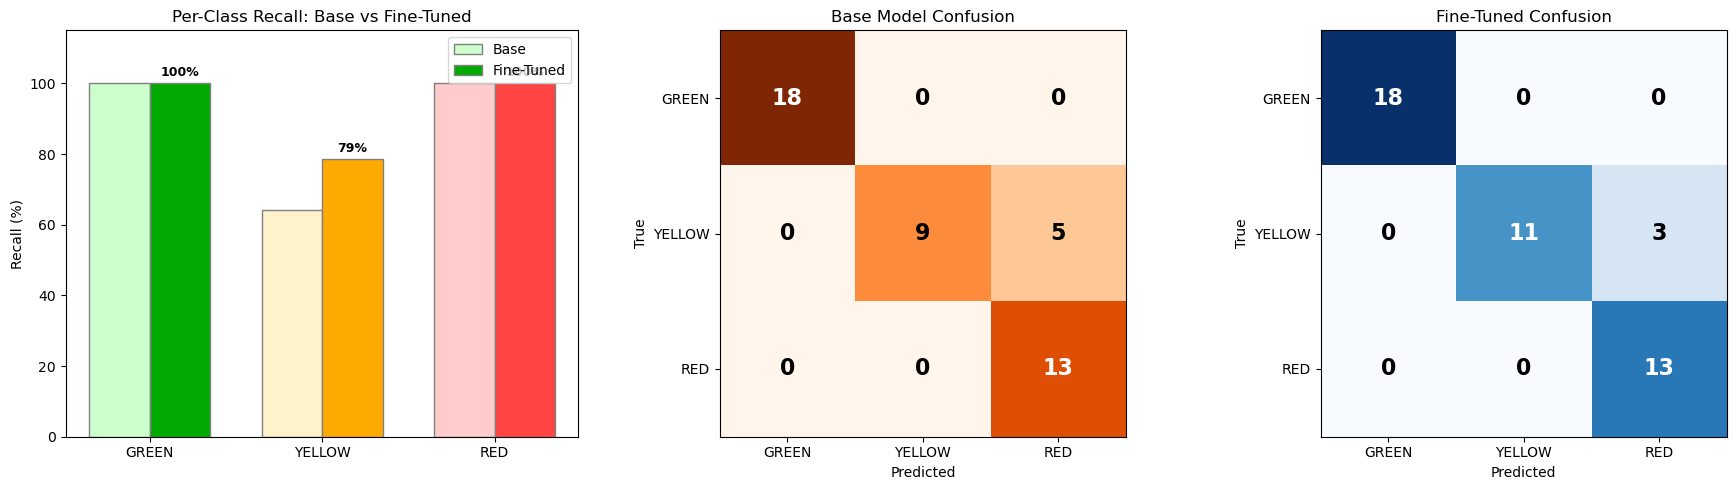

Saved: cairn_results_v2.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

levels = ["GREEN", "YELLOW", "RED"]
idx = {l: i for i, l in enumerate(levels)}

def compute_metrics(results):
    cm = np.zeros((3, 3), dtype=int)
    for r in results:
        cm[idx[r["expected"]], idx[r["predicted"]]] += 1
    metrics = {}
    for i, lv in enumerate(levels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        metrics[lv] = {"precision": precision, "recall": recall, "f1": f1,
                       "tp": tp, "fn": fn, "fp": fp, "total": int(cm[i, :].sum())}
    accuracy = sum(r["correct"] for r in results) / len(results)
    return cm, metrics, accuracy

base_cm, base_m, base_acc = compute_metrics(base_results)
ft_cm, ft_m, ft_acc = compute_metrics(ft_results)

print("=" * 70)
print(f"{'Metric':<25s} {'Base':>12s} {'Fine-Tuned':>12s} {'Delta':>8s}")
print("-" * 70)
print(f"{'Overall Accuracy':<25s} {base_acc:>11.0%} {ft_acc:>11.0%} {ft_acc-base_acc:>+7.0%}")
for lv in ["RED", "YELLOW", "GREEN"]:
    br, fr = base_m[lv]["recall"], ft_m[lv]["recall"]
    print(f"{lv + ' Recall':<25s} {br:>11.0%} {fr:>11.0%} {fr-br:>+7.0%}")
for lv in ["RED", "YELLOW", "GREEN"]:
    bf, ff = base_m[lv]["f1"], ft_m[lv]["f1"]
    print(f"{lv + ' F1':<25s} {bf:>11.2f} {ff:>11.2f} {ff-bf:>+7.2f}")
print("-" * 70)

red_recall = ft_m["RED"]["recall"]
if red_recall == 1.0:
    print("SAFETY CHECK: PASSED — RED recall = 100%")
else:
    print(f"SAFETY CHECK: FAILED — RED recall = {red_recall:.0%} ({ft_m['RED']['fn']} emergencies MISSED)")
    print("ACTION REQUIRED: Retrain with more RED boundary cases before deployment.")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(3); w = 0.35
base_recalls = [base_m[lv]["recall"] * 100 for lv in levels]
ft_recalls = [ft_m[lv]["recall"] * 100 for lv in levels]
axes[0].bar(x - w/2, base_recalls, w, label="Base", color=["#ccffcc", "#fff3cc", "#ffcccc"], edgecolor="gray")
axes[0].bar(x + w/2, ft_recalls, w, label="Fine-Tuned", color=["#00aa00", "#ffaa00", "#ff4444"], edgecolor="gray")
axes[0].set_xticks(x); axes[0].set_xticklabels(levels)
axes[0].set_ylim(0, 115); axes[0].set_ylabel("Recall (%)")
axes[0].set_title("Per-Class Recall: Base vs Fine-Tuned")
axes[0].legend()
for i, (b, f) in enumerate(zip(base_recalls, ft_recalls)):
    axes[0].text(i + w/2, f + 2, f"{f:.0f}%", ha="center", fontsize=9, fontweight="bold")

for ax, cm, title, cmap in [(axes[1], base_cm, "Base Model", "Oranges"), (axes[2], ft_cm, "Fine-Tuned", "Blues")]:
    ax.imshow(cm, cmap=cmap)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(levels); ax.set_yticklabels(levels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{title} Confusion")

plt.tight_layout()
plt.savefig("cairn_results_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cairn_results_v2.png")

In [14]:
# Error Analysis
ft_errors = [r for r in ft_results if not r["correct"]]
base_errors = [r for r in base_results if not r["correct"]]
exp_sev = {"GREEN": 0, "YELLOW": 1, "RED": 2}

print(f"Base errors: {len(base_errors)}/{len(base_results)}")
print(f"Fine-tuned errors: {len(ft_errors)}/{len(ft_results)}")

if ft_errors:
    print("\n" + "=" * 70)
    print("FINE-TUNED MODEL: ERROR ANALYSIS")
    print("=" * 70)
    for i, e in enumerate(ft_errors):
        direction = "OVER-TRIAGE (safe)" if exp_sev[e["predicted"]] > exp_sev[e["expected"]] else "UNDER-TRIAGE (DANGEROUS)"
        print(f"\n--- Error {i+1}: {e['expected']} -> {e['predicted']} [{direction}] ---")
        print(f"Category: {e['category']}")
        print(f"Patient: {e['desc']}")
        print(f"Response (first 300 chars): {e['response'][:300]}")

    under = [e for e in ft_errors if exp_sev[e["predicted"]] < exp_sev[e["expected"]]]
    over = [e for e in ft_errors if exp_sev[e["predicted"]] > exp_sev[e["expected"]]]
    print(f"\n{'='*70}")
    print(f"Error direction: {len(over)} over-triage (safe), {len(under)} under-triage (dangerous)")
    if under:
        print("UNDER-TRIAGE CASES (need retraining focus):")
        for e in under:
            print(f"  - {e['expected']}->{e['predicted']}: {e['desc'][:80]}")
else:
    print("\nPERFECT SCORE: No errors on 50 cases.")

Base errors: 5/45
Fine-tuned errors: 3/45

FINE-TUNED MODEL: ERROR ANALYSIS

--- Error 1: YELLOW -> RED [OVER-TRIAGE (safe)] ---
Category: clear
Patient: 50yo 8hr RLQ pain, periumbilical now localized. Rebound tenderness. Fever 38.2C. Vitals stable.
Response (first 300 chars): **Triage Level:** RED

**Assessment:** The patient presents with classic signs of acute appendicitis (migratory pain from periumbilical to RLQ, fever, and rebound tenderness). While vitals are currently stable, the presence of peritoneal signs (rebound tenderness) indicates an inflamed appendix that

--- Error 2: YELLOW -> RED [OVER-TRIAGE (safe)] ---
Category: clear
Patient: 14yo skateboard fall. Right forearm visibly angulated. Fingers pink, good cap refill. Pain 8/10.
Response (first 300 chars): **Triage Level:** RED

**Assessment:** High-energy injury with visible deformity (angulation) to the forearm. While distal neurovascular status is currently intact (pink fingers, good cap refill), the high pain level a

## Step 9: Save LoRA + Export GGUF

### A100 40GB: Memory management for GGUF export

`save_pretrained_gguf` merges LoRA into the base in 16-bit, then converts to GGUF. We aggressively free training state (optimizer, gradients, trainer) before export.

If OOM occurs during export, a recovery cell below reloads the model from saved LoRA without any training state.

In [15]:
# Save LoRA first (fast, always works)
model.save_pretrained("cairn-e4b-triage-lora")
tokenizer.save_pretrained("cairn-e4b-triage-lora")
import os
sz = sum(os.path.getsize(os.path.join("cairn-e4b-triage-lora", f))
         for f in os.listdir("cairn-e4b-triage-lora")
         if os.path.isfile(os.path.join("cairn-e4b-triage-lora", f)))
print(f"LoRA saved: {sz/1024**2:.0f} MB")

# Free training state before GGUF export (critical on A100 40GB)
try:
    del trainer, stats
except NameError:
    pass
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

gpu_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
print(f"GPU after cleanup: {torch.cuda.memory_allocated()/1024**3:.1f} GB used, {gpu_free:.1f} GB free")

LoRA saved: 354 MB
GPU after cleanup: 15.2 GB used, 24.3 GB free


In [16]:
!sudo apt-get update -qq 2>/dev/null && sudo apt-get install -y -qq libcurl4-openssl-dev libssl-dev cmake build-essential 2>&1 | tail -1
print("System deps installed for llama.cpp build")

No VM guests are running outdated hypervisor (qemu) binaries on this host.
System deps installed for llama.cpp build


In [17]:
import glob, shutil

CWD = os.getcwd()
GGUF_DIR = "cairn-gguf"

existing_ggufs = set(glob.glob(f"{CWD}/**/*.gguf", recursive=True) + glob.glob(f"{CWD}/*.gguf"))

gpu_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
print(f"Exporting GGUF (q4_k_m) — ~15-20 min...")
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.1f} GB used, {gpu_free:.1f} GB free")
if gpu_free < 20:
    print(f"WARNING: Only {gpu_free:.1f} GB free. If OOM, use the recovery cell below.")

try:
    model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")
    print("save_pretrained_gguf completed")
except Exception as e:
    print(f"save_pretrained_gguf raised: {e}")
    print("Checking if GGUF was written to CWD (known Unsloth quirk)...")

search_paths = [f"{GGUF_DIR}/**/*.gguf", f"{GGUF_DIR}*.gguf",
                f"{CWD}/*.gguf", f"{CWD}/**/*.gguf", f"{GGUF_DIR}_gguf/**/*.gguf"]
all_ggufs = set()
for pattern in search_paths:
    all_ggufs.update(glob.glob(pattern, recursive=True))

new_ggufs = [os.path.abspath(f) for f in all_ggufs - existing_ggufs if os.path.getsize(f) > 1024**3]
print(f"\nNew GGUF files: {len(new_ggufs)}")
for g in new_ggufs:
    print(f"  {g} ({os.path.getsize(g)/1024**3:.1f} GB)")

if new_ggufs:
    gguf_path = max(new_ggufs, key=os.path.getsize)
    final_q4 = "./cairn-e4b-triage-Q4_K_M.gguf"
    if os.path.abspath(gguf_path) != os.path.abspath(final_q4):
        shutil.copy2(gguf_path, final_q4)
    print(f"\nGGUF ready: {final_q4} ({os.path.getsize(final_q4)/1024**3:.1f} GB)")
    print(f"GPU peak: {torch.cuda.max_memory_allocated()/1024**3:.1f} GB")
else:
    final_q4 = None
    print("\nNo GGUF found. Try the OOM recovery cell below, or push LoRA only.")

Exporting GGUF (q4_k_m) — ~15-20 min...
GPU: 15.2 GB used, 24.3 GB free
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /home/ubuntu/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `cairn-gguf`: 100%|██████████| 1/1 [00:13<00:00, 13.69s/it]


Successfully copied all 1 files from cache to `cairn-gguf`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:18<00:00, 78.24s/it]


Unsloth: Merge process complete. Saved to `/home/ubuntu/cairn-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['cairn-gguf_gguf/gemma-4-E4B-it.BF16.gguf', 'cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['cairn-gguf_gguf/gemma-4-E4B-it.Q4_K_M.gguf', 'cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: /home/ubuntu/.unsloth/llama.cpp/llama-mtmd-cli -m cairn-gguf_gguf/gemma-4-E4B-it.Q4_K_M.gguf --mmproj cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to cairn-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f cairn-gguf_gguf/Modelfile
save_pretrained_gguf co

### OOM Recovery (A100 40GB fallback)

**Skip this cell if GGUF export succeeded above.**

If the export ran out of memory, this cell reloads the model fresh from the saved LoRA (no training state in memory), giving ~24GB free for the merge.

In [18]:
# # === SKIP if GGUF export succeeded above ===
# import gc, torch, glob, shutil, os

# # Nuke everything from GPU
# for var_name in ['model', 'trainer', 'dataset', 'model_v']:
#     if var_name in globals():
#         del globals()[var_name]
# gc.collect()
# torch.cuda.empty_cache()

# os.environ["ATTN_BACKEND"] = "eager"
# os.environ["TRANSFORMERS_NO_FLASH_ATTENTION"] = "1"

# from unsloth import FastVisionModel

# HF_TOKEN = "hf_YOUR_TOKEN_HERE"  # Same token

# # Reload from saved LoRA — no training state, minimal VRAM
# model, tokenizer = FastVisionModel.from_pretrained(
#     model_name="cairn-e4b-triage-lora",
#     max_seq_length=2048,
#     load_in_4bit=False,
#     token=HF_TOKEN,
# )
# gpu_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
# print(f"Fresh load: {torch.cuda.memory_allocated()/1024**3:.1f} GB used, {gpu_free:.1f} GB free")

# # Install build deps if needed
# !sudo apt-get update -qq 2>/dev/null && sudo apt-get install -y -qq libcurl4-openssl-dev libssl-dev cmake build-essential 2>&1 | tail -1

# CWD = os.getcwd()
# GGUF_DIR = "cairn-gguf"
# existing_ggufs = set(glob.glob(f"{CWD}/**/*.gguf", recursive=True) + glob.glob(f"{CWD}/*.gguf"))

# print("Retrying GGUF export with clean GPU memory...")
# model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")

# all_ggufs = set()
# for pattern in [f"{GGUF_DIR}/**/*.gguf", f"{GGUF_DIR}*.gguf", f"{CWD}/*.gguf",
#                 f"{CWD}/**/*.gguf", f"{GGUF_DIR}_gguf/**/*.gguf"]:
#     all_ggufs.update(glob.glob(pattern, recursive=True))
# new_ggufs = [os.path.abspath(f) for f in all_ggufs - existing_ggufs if os.path.getsize(f) > 1024**3]

# if new_ggufs:
#     gguf_path = max(new_ggufs, key=os.path.getsize)
#     final_q4 = "./cairn-e4b-triage-Q4_K_M.gguf"
#     if os.path.abspath(gguf_path) != os.path.abspath(final_q4):
#         shutil.copy2(gguf_path, final_q4)
#     print(f"GGUF ready: {final_q4} ({os.path.getsize(final_q4)/1024**3:.1f} GB)")
# else:
#     final_q4 = None
#     print("Still no GGUF. Push LoRA only — export later from HF weights.")

## Step 10: Push to HuggingFace

Published artifacts:
- **LoRA adapters** — load on any E4B for inference or further training
- **GGUF Q4_K_M** (~5GB) — drop into Ollama for offline deployment
- **GGUF Q8_0** (~8GB) — higher fidelity for safety-critical triage

In [19]:
from huggingface_hub import HfApi
HF_USERNAME = "lightmate"  # Change to your HF username
api = HfApi()

# 1. Push LoRA
print("Pushing LoRA adapters...")
model.push_to_hub(f"{HF_USERNAME}/cairn-gemma4-e4b-triage", token=HF_TOKEN)
tokenizer.push_to_hub(f"{HF_USERNAME}/cairn-gemma4-e4b-triage", token=HF_TOKEN)
print(f"LoRA: huggingface.co/{HF_USERNAME}/cairn-gemma4-e4b-triage")

# 2. Push GGUF Q4_K_M
if final_q4 and os.path.exists(final_q4) and os.path.getsize(final_q4) > 1024**3:
    GGUF_REPO = f"{HF_USERNAME}/cairn-gemma4-e4b-triage-gguf"
    api.create_repo(GGUF_REPO, exist_ok=True, token=HF_TOKEN)
    print(f"\nPushing Q4_K_M ({os.path.getsize(final_q4)/1024**3:.1f} GB)...")
    api.upload_file(path_or_fileobj=final_q4, path_in_repo="cairn-e4b-triage-Q4_K_M.gguf",
                    repo_id=GGUF_REPO, token=HF_TOKEN)
    # Upload mmproj if exists
    for mp in glob.glob(f"{GGUF_DIR}_gguf/*mmproj*") + glob.glob(f"{GGUF_DIR}/*mmproj*"):
        print(f"Pushing mmproj: {os.path.basename(mp)}")
        api.upload_file(path_or_fileobj=mp, path_in_repo=os.path.basename(mp),
                        repo_id=GGUF_REPO, token=HF_TOKEN)

    # 3. Push Q8_0 (free GPU first — A100 is tight)
    gc.collect(); torch.cuda.empty_cache()
    print("\nPushing Q8_0...")
    try:
        model.push_to_hub_gguf(f"{HF_USERNAME}/cairn-gemma4-e4b-triage-gguf",
                               tokenizer, quantization_method="q8_0", token=HF_TOKEN)
        print("Q8_0 pushed")
    except Exception as e:
        print(f"Q8_0 push failed (likely OOM on A100 40GB): {e}")
        print("Q4_K_M is published. Q8_0 can be exported later on a larger instance.")
else:
    print("\nGGUF not available. LoRA adapters published.")

print("\n" + "=" * 60 + "\nAll artifacts published!\n" + "=" * 60)

Pushing LoRA adapters...


Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1):   0%|          |  757kB /  339MB,  236kB/s  
Processing Files (0 / 1):   0%|          | 1.38MB /  339MB,  364kB/s  
Processing Files (0 / 1):   1%|          | 2.63MB /  339MB,  627kB/s  
Processing Files (0 / 1):   1%|▏         | 4.44MB /  339MB, 1.01MB/s  
Processing Files (0 / 1):   2%|▏         | 6.94MB /  339MB, 1.51MB/s  
Processing Files (0 / 1):   3%|▎         | 9.42MB /  339MB, 1.88MB/s  
Processing Files (0 / 1):   3%|▎         | 9.97MB /  339MB, 1.92MB/s  
Processing Files (0 / 1):   4%|▍         | 13.1MB /  339MB, 2.43MB/s  
Processing Files (0 / 1):   7%|▋         | 25.0MB /  339MB, 4.47MB/s  
Processing Files (0 / 1):   8%|▊         | 27.9MB /  339MB, 4.81MB/s  
Processing Files (0 / 1):   9%|▉         | 29.8MB /  339MB, 4.96MB/s  
Processing Files (0 / 1):  10%|▉         | 33.7MB /  339MB, 5.43MB/s  
Processing Files (0 / 1):  12%|█▏        | 40.2MB /  339MB, 6.28MB/s  
Processing

Saved model to https://huggingface.co/lightmate/cairn-gemma4-e4b-triage


Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (1 / 1): 100%|██████████| 32.2MB / 32.2MB, 3.22MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


LoRA: huggingface.co/lightmate/cairn-gemma4-e4b-triage

Pushing Q4_K_M (5.0 GB)...


...

Uploading config.json...


No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Uploading Ollama Modelfile...


No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Unsloth: Successfully uploaded GGUF to https://huggingface.co/lightmate/cairn-gemma4-e4b-triage-gguf
Unsloth: Cleaning up temporary files...
Q8_0 pushed

All artifacts published!


## Step 11: Verify from HuggingFace

Load published LoRA back on a fresh model. Proves weights are valid and reproducible.

In [20]:
del model
gc.collect(); torch.cuda.empty_cache()

model_v, tok_v = FastVisionModel.from_pretrained(
    model_name=f"{HF_USERNAME}/cairn-gemma4-e4b-triage",
    max_seq_length=2048, load_in_4bit=True, token=HF_TOKEN,
)
FastVisionModel.for_inference(model_v)

verify_cases = [
    ("25yo, paper cut on finger, bleeding stopped.", "GREEN"),
    ("14yo, forearm visibly angulated after fall. Pink fingers.", "YELLOW"),
    ("60yo crushing chest pain, diaphoretic, BP 90/60.", "RED"),
]

print("Verification from HuggingFace:")
for desc, expected in verify_cases:
    msgs = [{"role": "user", "content": [{"type": "text",
             "text": f"Triage this patient. Respond with triage level (RED/YELLOW/GREEN), "
                     f"brief assessment, and confidence.\n\nPatient: {desc}"}]}]
    inputs = tok_v.apply_chat_template(msgs, tokenize=True, return_tensors="pt",
                                       add_generation_prompt=True).to(model_v.device)
    with torch.no_grad():
        out = model_v.generate(input_ids=inputs, max_new_tokens=256, temperature=0.1)
    resp = tok_v.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True)
    pred = extract_triage_level(resp)
    mark = "PASS" if pred == expected else "FAIL"
    print(f"  [{mark}] Expected: {expected}, Got: {pred} | {desc[:60]}")

==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2130/2130 [00:01<00:00, 1078.58it/s]


Verification from HuggingFace:
  [PASS] Expected: GREEN, Got: GREEN | 25yo, paper cut on finger, bleeding stopped.
  [PASS] Expected: YELLOW, Got: YELLOW | 14yo, forearm visibly angulated after fall. Pink fingers.
  [PASS] Expected: RED, Got: RED | 60yo crushing chest pain, diaphoretic, BP 90/60.


## Deploy: Ollama (Offline)

```bash
# Download GGUF
huggingface-cli download lightmate/cairn-gemma4-e4b-triage-gguf \
  --include "*.gguf" --local-dir ./cairn-gguf

# Create Ollama model
cat > Modelfile << 'EOF'
FROM ./cairn-gguf/cairn-e4b-triage-Q4_K_M.gguf
PARAMETER temperature 0.1
PARAMETER num_ctx 4096
PARAMETER num_predict 1024
PARAMETER stop <turn|>
SYSTEM "You are Cairn, an offline medical triage assistant for community health workers. For each patient, provide: 1) Triage level (RED/YELLOW/GREEN), 2) Brief clinical assessment, 3) Actionable recommendations, 4) Confidence (0.0-1.0). Respond directly with the triage level first."
EOF

ollama create cairn-e4b-triage -f Modelfile
ollama run cairn-e4b-triage "Patient: 25yo paper cut on finger, bleeding stopped."
```

**Note**: `num_predict 1024` is required — Gemma 4 enters extended thinking mode before generating.

---

## Summary

| What | Result |
|------|--------|
| **Hardware** | 1x A100 40GB SXM4 (Lambda) |
| **Technique** | Teacher-student distillation (26B-A4B → E4B) |
| **Training data** | 130 examples from WHO ETAT + ESI scenarios |
| **Training time** | ~10 min (160 steps, batch 4) |
| **Eval** | 50 cases: clear + boundary + adversarial |
| **Published** | LoRA + GGUF Q4_K_M on HuggingFace |
| **Deployment** | Single GGUF → Ollama → fully offline |

**[Cairn GitHub](https://github.com/rkstu/cairn)** | **[HuggingFace Weights](https://huggingface.co/lightmate/cairn-gemma4-e4b-triage)** | **[Training Data](https://kaggle.com/datasets/rahulkumar99/cairn-triage-distillation)** | **[Unsloth](https://github.com/unslothai/unsloth)** | **[Gemma 4](https://ai.google.dev/gemma/docs)**